In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

In [2]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

In [3]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


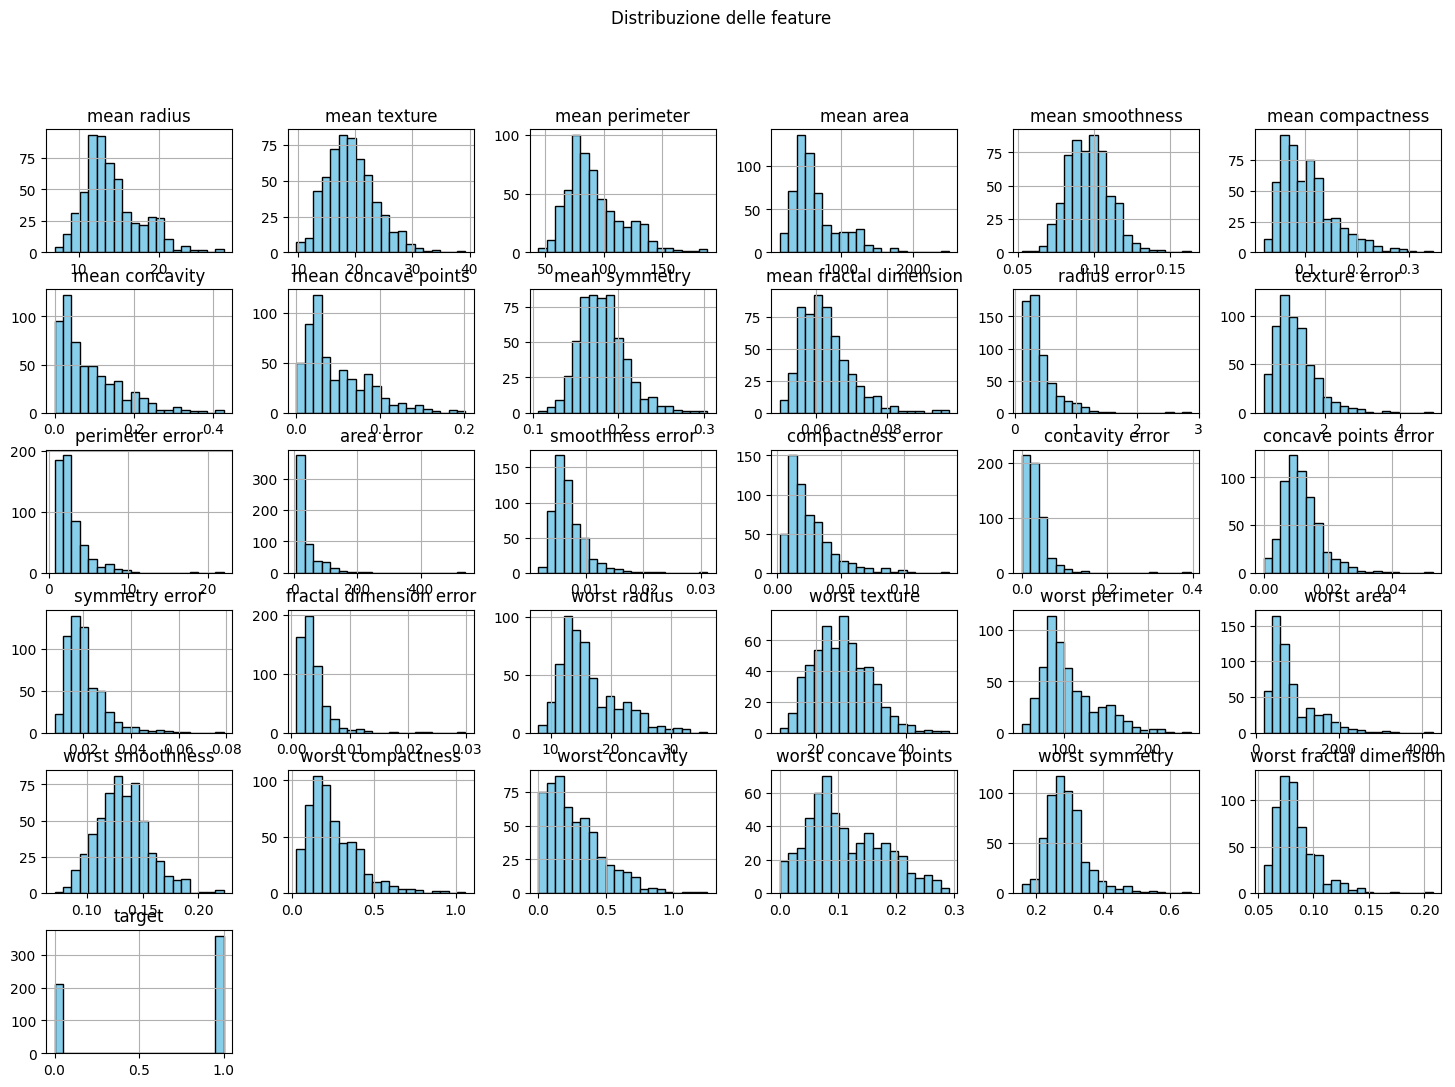

In [4]:
df.hist(bins=20, figsize=(18,12), color='skyblue', edgecolor='black')
plt.suptitle("Distribuzione delle feature")
plt.show()

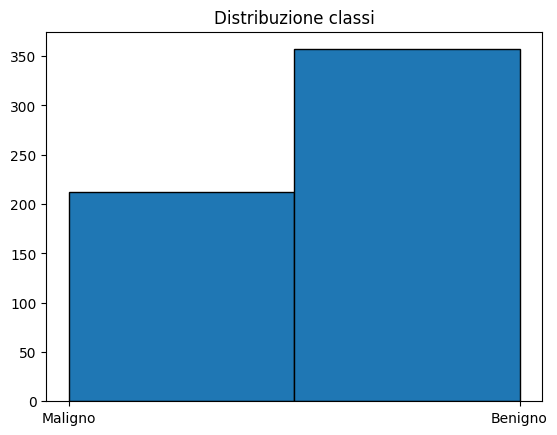

In [5]:
plt.hist(df['target'], bins=2, edgecolor='black')
plt.xticks([0,1], ['Maligno','Benigno'])
plt.title("Distribuzione classi")
plt.show()

In [6]:
features = ['mean radius', 'mean texture']
X = df[features].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = DecisionTreeClassifier(random_state=42, max_depth=3, min_samples_leaf=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport di classificazione:\n", classification_report(y_test, y_pred))

Accuracy: 0.9210526315789473

Report di classificazione:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90        43
           1       0.96      0.92      0.94        71

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



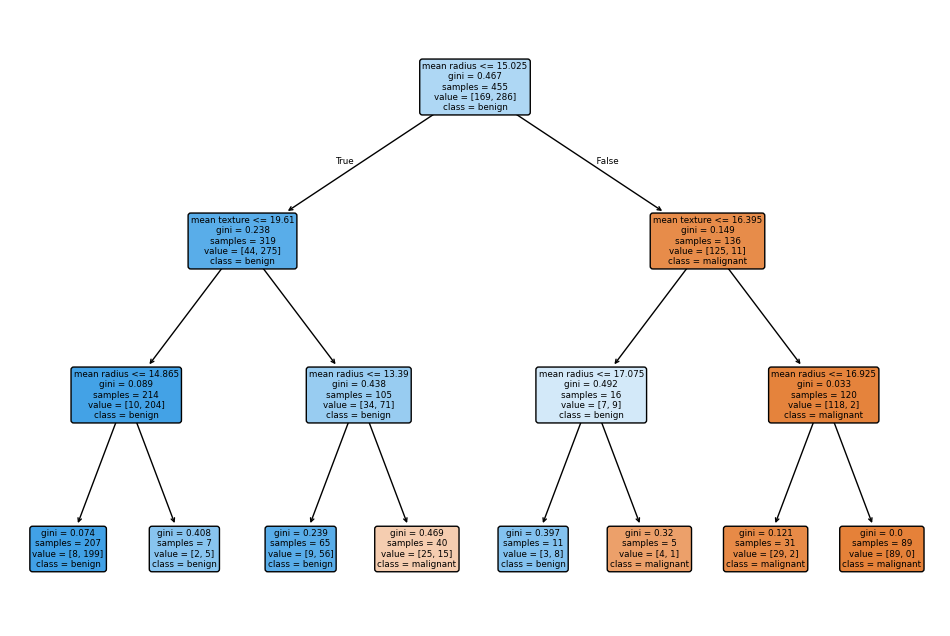

In [9]:
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=features, class_names=cancer.target_names,
          filled=True, rounded=True)
plt.show()

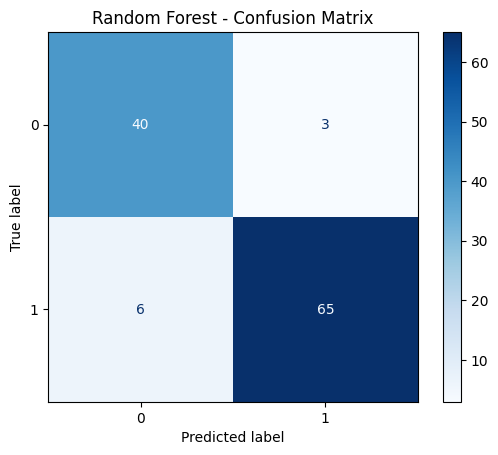

In [10]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues)
plt.title("Random Forest - Confusion Matrix")
plt.show()

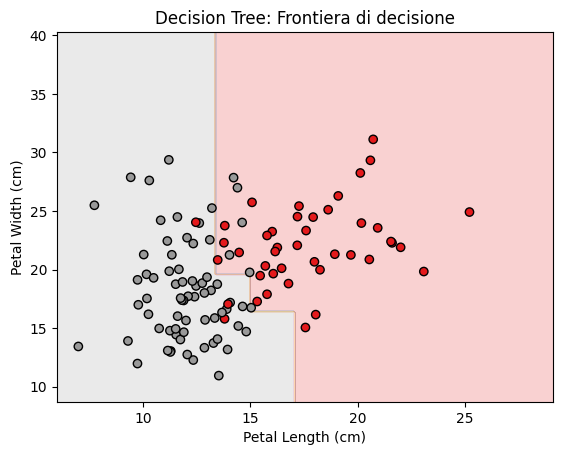

In [11]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.Set1)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, edgecolors='k', cmap=plt.cm.Set1)
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Decision Tree: Frontiera di decisione")
plt.show()

In [12]:
best_features = [
    'worst radius',
    'worst perimeter',
    'worst concave points',
    'mean concave points',
    'mean perimeter',
    'mean radius',
    'area error',
    'worst area'
]

X_best = df[best_features].values

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_best, y, test_size=0.2, random_state=42)

In [13]:
model_best = DecisionTreeClassifier(random_state=42, max_depth=4, min_samples_leaf=5)
model_best.fit(X_train_b, y_train_b)
y_pred_b = model_best.predict(X_test_b)

In [14]:
print("Accuracy:", accuracy_score(y_test_b, y_pred_b))
print("\nReport di classificazione:\n", classification_report(y_test_b, y_pred_b))

Accuracy: 0.9298245614035088

Report di classificazione:
               precision    recall  f1-score   support

           0       0.95      0.86      0.90        43
           1       0.92      0.97      0.95        71

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



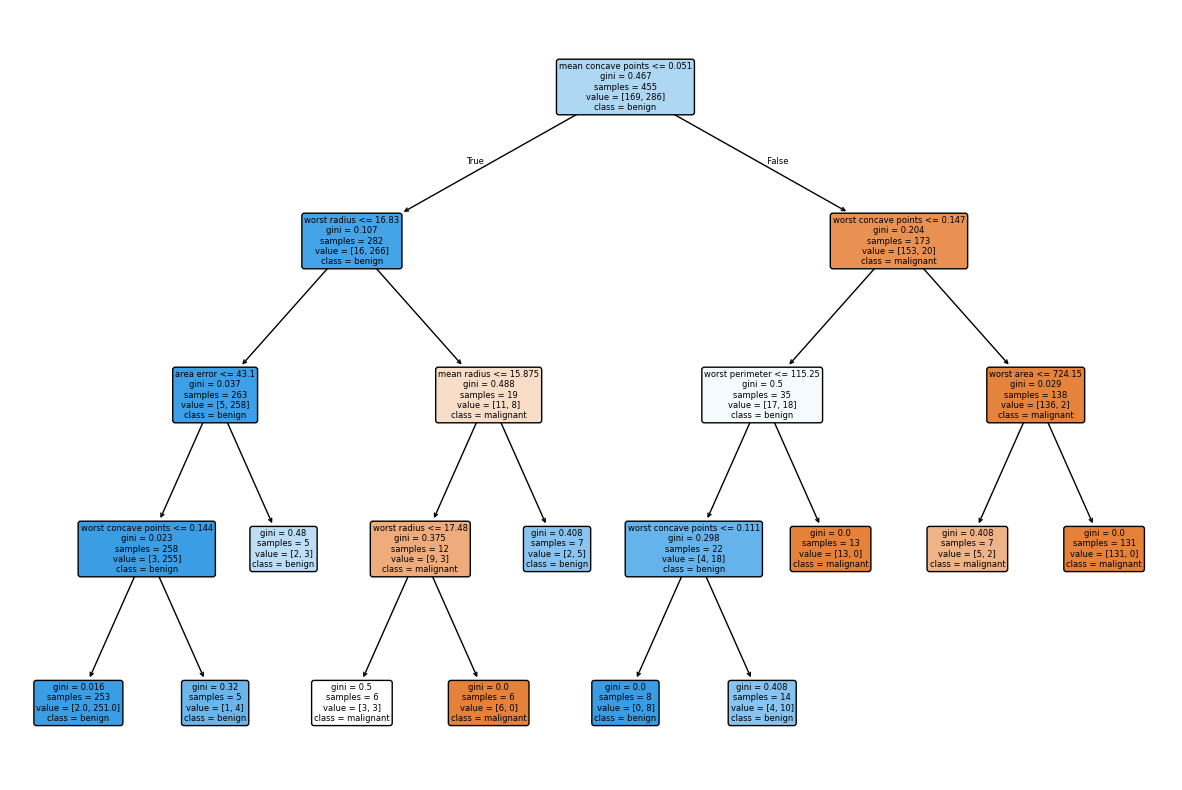

In [15]:
plt.figure(figsize=(15,10))
plot_tree(model_best, feature_names=best_features, class_names=cancer.target_names,
          filled=True, rounded=True)
plt.show()

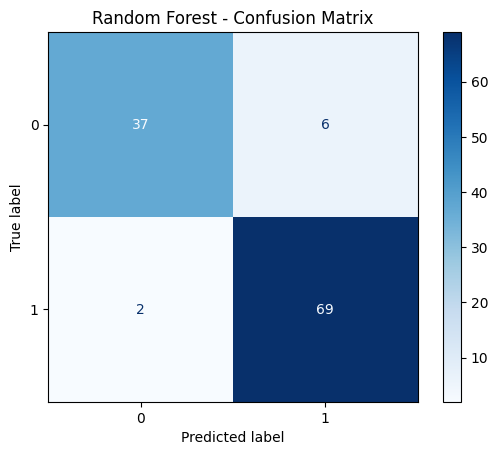

In [16]:
ConfusionMatrixDisplay.from_estimator(model_best, X_test_b, y_test_b, cmap=plt.cm.Blues)
plt.title("Random Forest - Confusion Matrix")
plt.show()